In [1]:
# Q9 =

Simulations per step count = 200000, seed = 50

After  5 steps: estimated probability of exit = 0.80729
After 10 steps: estimated probability of exit = 0.96267
After 20 steps: estimated probability of exit = 0.99869
After 30 steps: estimated probability of exit = 0.99992


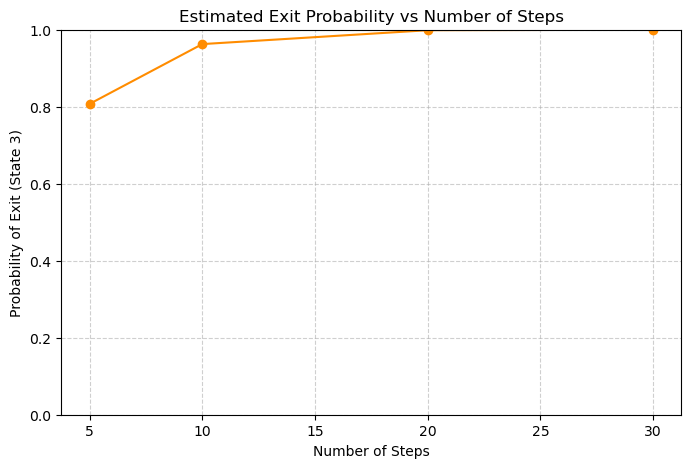

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Transition matrix for Markov chain (4 states, last is absorbing)
transition_matrix = np.array([
    [0.00, 0.50, 0.40, 0.10],
    [0.40, 0.00, 0.40, 0.20],
    [0.35, 0.50, 0.00, 0.15],
    [0.00, 0.00, 0.00, 1.00],
])

def simulate_exit_prob(num_steps, simulations=100_000, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)

    current_states = np.zeros(simulations, dtype=np.int8)  # start all at state 0

    for _ in range(num_steps):
        for state in (0, 1, 2):
            mask = (current_states == state)
            count = mask.sum()
            if count > 0:
                current_states[mask] = np.random.choice(4, size=count, p=transition_matrix[state])

    exit_prob = (current_states == 3).mean()
    return exit_prob

if __name__ == "__main__":
    steps_list = [5, 10, 20, 30]
    num_simulations = 200_000
    seed = 50

    exit_probabilities = []

    print(f"Simulations per step count = {num_simulations}, seed = {seed}\n")
    for steps in steps_list:
        prob = simulate_exit_prob(steps, simulations=num_simulations, random_seed=seed)
        exit_probabilities.append(prob)
        print(f"After {steps:2d} steps: estimated probability of exit = {prob:.5f}")

    # Plotting the results
    plt.figure(figsize=(8,5))
    plt.plot(steps_list, exit_probabilities, marker='o', linestyle='-', color='darkorange')
    plt.title('Estimated Exit Probability vs Number of Steps')
    plt.xlabel('Number of Steps')
    plt.ylabel('Probability of Exit (State 3)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 1)
    plt.show()
